In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'First Dataset.xlsx'
df = pd.read_excel(file_path, sheet_name=0)

print(f"تعداد سطرهای اولیه: {len(df)}")

df_clean = df.drop_duplicates().reset_index(drop=True)

median_age = df_clean[df_clean['age'] <= 100]['age'].median()
df_clean.loc[df_clean['age'] > 100, 'age'] = median_age

df_clean['age'] = df_clean['age'].fillna(median_age).astype(int)

df_clean['total_spending'] = (df_clean['purchase_count'] * df_clean['avg_order_value']).round(2)

male_names = ['Reza', 'Sina', 'Parsa', 'Amir', 'Arash', 'Ali']
female_names = ['Kimia', 'Neda', 'Mina', 'Zahra', 'Maryam', 'Sara']

def correct_gender(row):
    if row['first_name'] in male_names:
        return 'M'
    elif row['first_name'] in female_names:
        return 'F'
    return row['gender']

df_clean['gender'] = df_clean.apply(correct_gender, axis=1)

df_clean['returned_items'] = df_clean[['returned_items', 'purchase_count']].min(axis=1)

df_clean['signup_date'] = pd.to_datetime(df_clean['signup_date'])

output_file = 'Cleaned_Customers_Dataset.xlsx'
df_clean.to_excel(output_file, index=False)

print(f"تعداد سطرهای نهایی پس از پاک‌سازی: {len(df_clean)}")
print("پاک‌سازی با موفقیت انجام شد و فایل جدید ذخیره گردید.")

تعداد سطرهای اولیه: 61
تعداد سطرهای نهایی پس از پاک‌سازی: 60
پاک‌سازی با موفقیت انجام شد و فایل جدید ذخیره گردید.


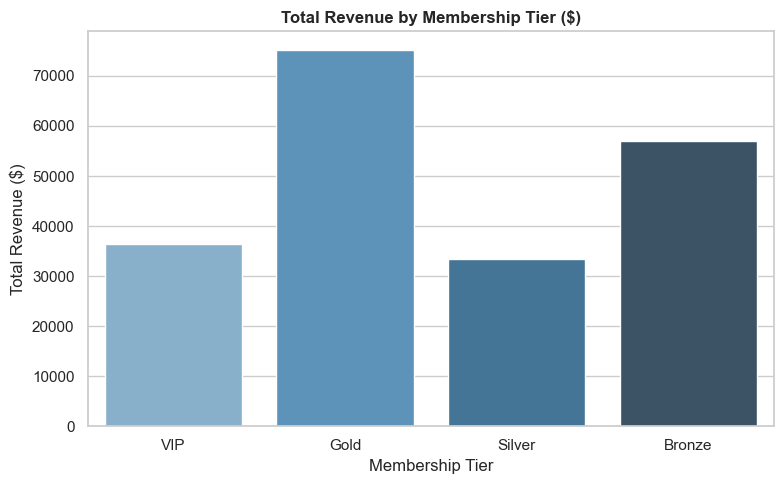

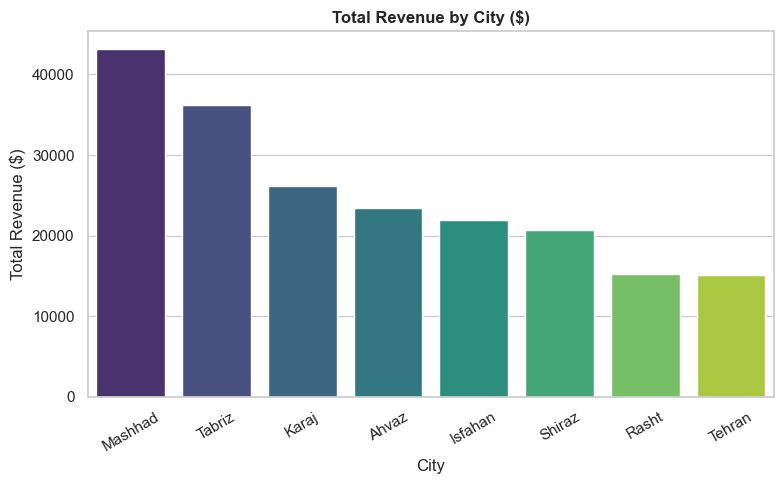

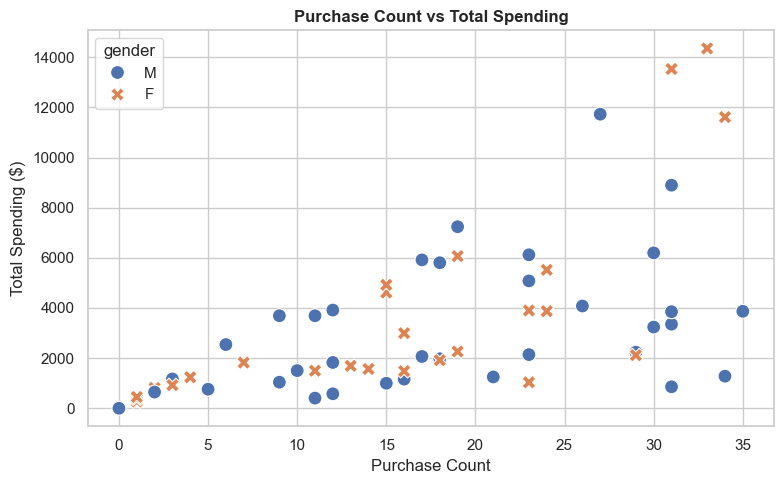

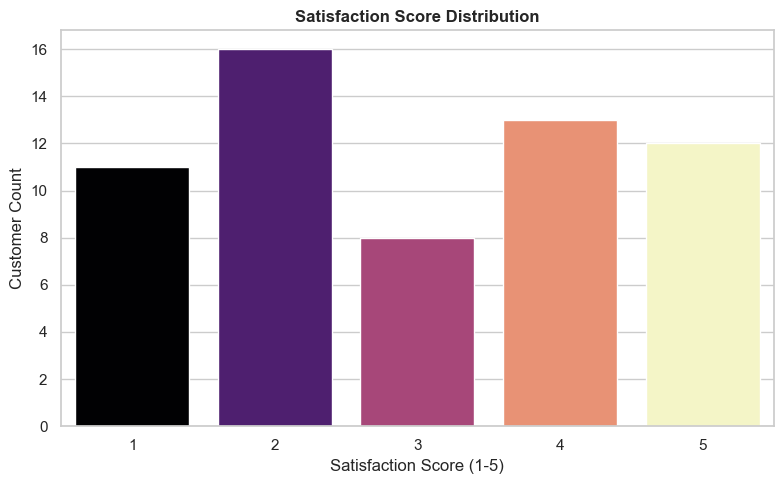

--- درآمد کل بر اساس شهر ---
      city  total_spending
0  Mashhad        43197.58
1   Tabriz        36192.49
2    Karaj        26189.81
3    Ahvaz        23384.78
4  Isfahan        21975.32
5   Shiraz        20715.92
6    Rasht        15168.54
7   Tehran        15161.29

--- میانگین خرید بر اساس سطح عضویت ---
membership_tier
Bronze    3166.656111
Gold      3955.431579
Silver    4179.926250
VIP       2426.220667
Name: total_spending, dtype: float64


In [9]:
df = pd.read_excel('Cleaned_Customers_Dataset.xlsx')

sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. نمودار اول: درآمد کل بر اساس سطح عضویت
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df, 
    x='membership_tier', 
    y='total_spending', 
    hue='membership_tier', 
    estimator=sum, 
    errorbar=None, 
    palette='Blues_d',
    legend=False
)
plt.title('Total Revenue by Membership Tier ($)', fontsize=12, fontweight='bold')
plt.xlabel('Membership Tier')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
plt.savefig('01_revenue_by_membership_tier.png', dpi=300)
plt.show()

# ---------------------------------------------------------
# 2. نمودار دوم: درآمد کل بر اساس شهر
# ---------------------------------------------------------
city_spend = df.groupby('city')['total_spending'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    data=city_spend, 
    x='city', 
    y='total_spending', 
    hue='city', 
    palette='viridis',
    legend=False
)
plt.title('Total Revenue by City ($)', fontsize=12, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('02_revenue_by_city.png', dpi=300)
plt.show()

# ---------------------------------------------------------
# 3. نمودار سوم: رابطه تعداد خرید و کل مبلغ پرداختی
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, 
    x='purchase_count', 
    y='total_spending', 
    hue='gender', 
    style='gender', 
    s=100
)
plt.title('Purchase Count vs Total Spending', fontsize=12, fontweight='bold')
plt.xlabel('Purchase Count')
plt.ylabel('Total Spending ($)')
plt.tight_layout()
plt.savefig('03_purchase_vs_spending.png', dpi=300)
plt.show()

# ---------------------------------------------------------
# 4. نمودار چهارم: توزیع امتیاز رضایت مشتریان
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df, 
    x='satisfaction_score', 
    hue='satisfaction_score', 
    palette='magma',
    legend=False
)
plt.title('Satisfaction Score Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Satisfaction Score (1-5)')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.savefig('04_satisfaction_score_distribution.png', dpi=300)
plt.show()

print("--- درآمد کل بر اساس شهر ---")
print(city_spend)

print("\n--- میانگین خرید بر اساس سطح عضویت ---")
print(df.groupby('membership_tier')['total_spending'].mean())

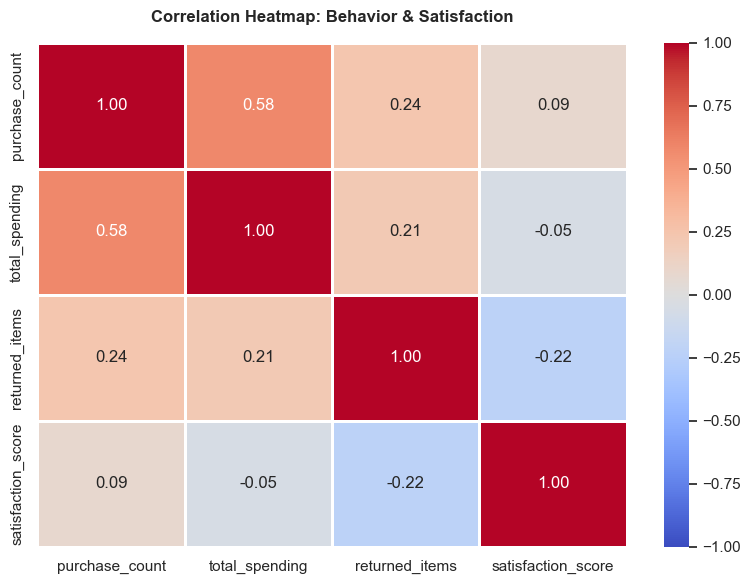

In [11]:
plt.figure(figsize=(8, 6))
cols = ['purchase_count', 'total_spending', 'returned_items', 'satisfaction_score']
corr_matrix = df[cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, cbar=True, linewidths=1)
plt.title('Correlation Heatmap: Behavior & Satisfaction', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('05_correlation_heatmap.png', dpi=300)
plt.show()

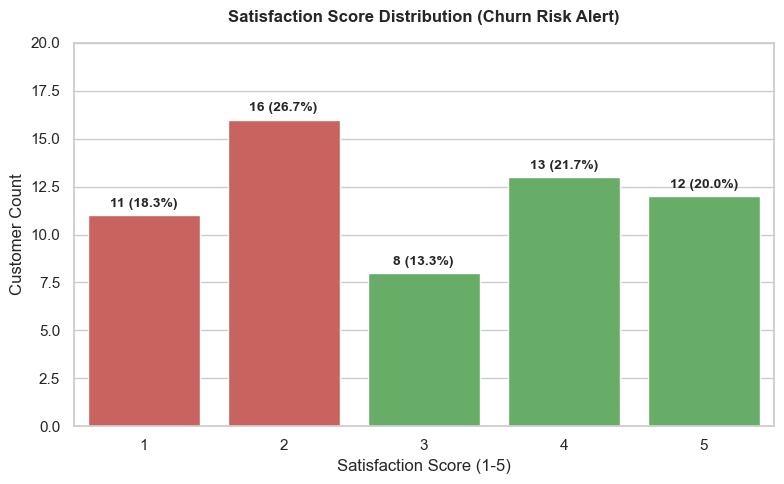

In [12]:
plt.figure(figsize=(8, 5))
sat_counts = df['satisfaction_score'].value_counts().sort_index().reset_index()
sat_counts.columns = ['satisfaction_score', 'count']

colors = ['#d9534f' if x <= 2 else '#5cb85c' for x in sat_counts['satisfaction_score']]

ax = sns.barplot(
    data=sat_counts, 
    x='satisfaction_score', 
    y='count', 
    hue='satisfaction_score',
    palette=colors,
    legend=False 
)

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.title('Satisfaction Score Distribution (Churn Risk Alert)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Satisfaction Score (1-5)')
plt.ylabel('Customer Count')
plt.ylim(0, max(sat_counts['count']) + 4)
plt.tight_layout()
plt.savefig('06_satisfaction_distribution.png', dpi=300)
plt.show()